In [1]:

import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys

epoch_path = "E:/workspace/kiki_conformity_data/Trust_Clean2" # 分析哪个roi就输入哪个文件夹的数据
behavior_path = "E:/workspace/kiki_conformity_data/Find_trials_combine" # 分析哪个roi就输入哪个文件夹的数据

subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

# subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

len(subjects)

channel_location_dict = {"Fp1":	[-26.25, 83, -18.25],
"Fp2": [26.25, 83, -18.25],
"F3": [-48.75, 57.5, 36.5],
"F4": [48.75, 57.5, 36.5],
"C3": [-63.75, -13, 65.75],
"C4": [63.75, -13, 65.75],
"P3": [-48, -86.5, 53],
"P4": [48, -86.5, 53],
"O1": [-27, -118, 4.25],
"O2": [27, -118, 4.25],
"F7": [-69, 44, -18.25],
"F8": [69, 44, -18.25],
"T7": [-84, -18.25, -13],
"T8": [84, -18.25, -13],
"P7": [-69, -80.5, -4.75],
"P8": [69, -80.5, -4.75],
"Fz": [0, 63.5, 59],
"Cz": [0, -10, 99.5],
"Pz": [0, -88, 77],
"FC1": [-32.25, 28.25, 77.75],
"FC2": [32.25, 28.25, 77.75],
"CP1": [-35.25, -52, 90.5],
"CP2": [35.25, -52, 90.5],
"FC5": [-75.75, 20, 21.5],
"FC6": [75.75, 20, 21.5],
"CP5": [-78, -51.25, 31.25],
"CP6": [78, -51.25, 31.25],
"FT9": [-72.75, 8.75, -55.75],
"FT10": [72.75, 8.75, -55.75],
"TP9": [-71.25, -49, -49.75],
"TP10": [71.25, -49, -49.75],
"F1": [-25.5, 62, 53.75],
"F2": [25.5, 62, 53.75],
"C1": [-35.25, -11.5, 89.75],
"C2": [35.25, -11.5, 89.75],
"P1": [-27, -88, 70.25],
"P2": [27, -88, 70.25],
"AF3": [-32.25, 80.75, 11.75],
"AF4": [32.25, 80.75, 11.75],
"FC3": [-59.25, 25.25, 54.5],
"FC4": [59.25, 25.25, 54.5],
"CP3": [-63, -52, 66.5],
"CP4": [63, -52, 66.5],
"PO3": [-31.5, -109.75, 32.75],
"PO4": [31.5, -109.75, 32.75],
"F5": [-63, 51.5, 11.75],
"F6": [63, 51.5, 11.75],
"C5": [-81.75, -14.5, 29],
"C6": [81.75, -14.5, 29],
"P5": [-63.75, -83.5, 26.75],
"P6": [63.75, -83.5, 26.75],
"AF7": [-50.25, 68, -19],
"AF8": [50.25, 68, -19],
"FT7": [-79.5, 15.5, -16],
"FT8": [79.5, 15.5, -16],
"TP7": [-80.25, -49.75, -8.5],
"TP8": [80.25, -49.75, -8.5],
"PO7": [-50.25, -103, 0.5],
"PO8": [50.25, -103, 0.5],
"Fpz": [0, 83, -18.25],
"CPz": [0, -53.5, 98],
"POz": [0, -109, 44],
"Oz": [0, -122.5, 8]}
# ['Fp1', 'Fp2', 'Fz', 'Cz', 'Pz', 'Fpz', 'CPz', 'POz', 'Oz'].
mymontage = mne.channels.make_dig_montage(ch_pos=channel_location_dict)#, nasion=[0, -10, 99.5], lpa=[-71.25, -49, -49.75], 
#                                        rpa=[71.25, -49, -49.75])

In [58]:
#个体水平
from mne.time_frequency import tfr_morlet
from pathlib import Path

freqs=np.arange(4, 8, 1)
# freqs=np.arange(8, 13, 1)
# freqs=np.arange(13, 30, 1)

# n_cycles = 10
n_cycles=freqs/4  # 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


# n_cycles =4
time_span = 100
ch_names = []
decision_time_range = [-1.0, 5] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s


all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


    # 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    # task_10_rows = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_human = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_AI = behavior_trial[behavior_trial['image_type'] == 309]

    human_indices = task_30_human.index.tolist()  # 正差组的行索引
    ai_indices = task_30_AI.index.tolist()  # 负差组的行索引

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[human_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[ai_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.2, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.2, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配




<ipython-input-58-80de2c2d551a>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-58-80de2c2d551a>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed:    1.1s


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    1.4s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-58-80de2c2d551a>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-58-80de2c2d551a>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


...

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-58-80de2c2d551a>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-58-80de2c2d551a>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


In [47]:
#先对epoch进行剪切
from mne.time_frequency import tfr_morlet
from pathlib import Path
import numpy as np
import pandas as pd
import mne

freqs = np.arange(4, 8, 1)
n_cycles = freqs / 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:
        n_cycles[i] = 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10

# Define time window around feedback_time (before performing TFR)
pre_feedback = 0.6  # time before feedback to include (600ms)
post_feedback = 1.1  # time after feedback to include (1100ms)

all_sub_human_data = []
all_sub_AI_data = []

# 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)

    # 提取不同条件是第几个试次
    task_30_human = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_AI = behavior_trial[behavior_trial['image_type'] == 309]

    human_indices = task_30_human.index.tolist()  # 正差组的行索引
    ai_indices = task_30_AI.index.tolist()  # 负差组的行索引
    
    if not human_indices or not ai_indices:
        continue

    # 获取两组 trials 的 feedback_time (in seconds)
    human_fbt = behavior_trial.loc[human_indices, 'feedback_time'].values / 1000
    ai_fbt = behavior_trial.loc[ai_indices, 'feedback_time'].values / 1000

    ################ 对齐human
    # 将列表转换为 numpy 数组以便处理 nan
    human_indices_arr = np.array(human_indices)
    human_fbt_arr = np.array(human_fbt)

    # 找出两个数组中不是 nan 的索引
    valid_mask = ~np.isnan(human_indices_arr) & ~np.isnan(human_fbt_arr)

    # 应用掩码过滤两个数组
    human_indices = human_indices_arr[valid_mask].tolist()
    human_fbt = human_fbt_arr[valid_mask].tolist()


    ##### chuli AI
    # 将列表转换为 numpy 数组以便处理 nan
    ai_indices_arr = np.array(ai_indices)
    ai_fbt_arr = np.array(ai_fbt)

    # 找出两个数组中不是 nan 的索引
    valid_mask = ~np.isnan(ai_indices_arr) & ~np.isnan(ai_fbt_arr)

    # 应用掩码过滤两个数组
    ai_indices = ai_indices_arr[valid_mask].tolist()
    ai_fbt = ai_fbt_arr[valid_mask].tolist()

    # Function to create aligned epochs for each trial
    def create_aligned_epochs(epochs, indices, feedback_times):
        aligned_data = []
        for idx, fb_time in zip(indices, feedback_times):
            # Get the original epoch data (shape: (1, n_channels, n_times))
            epoch_data = epochs[idx].get_data()
            
            # Find the time point corresponding to feedback_time
            tmin_original = epochs.times[0]
            feedback_sample = int((fb_time - tmin_original) * epochs.info['sfreq'])
            
            # Calculate new crop boundaries
            start_sample = feedback_sample - int(pre_feedback * epochs.info['sfreq'])
            end_sample = feedback_sample + int(post_feedback * epochs.info['sfreq'])
            
            # Check if crop boundaries are valid
            if start_sample < 0 or end_sample > epoch_data.shape[-1]:
                print(f"Skipping trial {idx} - crop out of bounds")
                continue
            
            # Crop the data around feedback_time (keep channel dimension)
            cropped_data = epoch_data[:, :, start_sample:end_sample]  # shape: (1, n_channels, n_samples)
            aligned_data.append(cropped_data)
        
        if not aligned_data:
            print("No valid trials after alignment")
            return None
    
        # Combine all trials (shape: (n_trials, n_channels, n_samples))
        combined_data = np.concatenate(aligned_data, axis=0)
        
        # Create new epochs object with aligned data
        aligned_epochs = mne.EpochsArray(
            data=combined_data,
            info=epochs.info,
            tmin=-pre_feedback,
            # events=np.zeros((len(aligned_data), 3)),  # dummy events
            verbose=False
        )
        return aligned_epochs

    # Create aligned epochs for both conditions
    human_aligned_epochs = create_aligned_epochs(EEG_epochs, human_indices, human_fbt)
    AI_aligned_epochs = create_aligned_epochs(EEG_epochs, ai_indices, ai_fbt)

    # Skip if no valid epochs
    if human_aligned_epochs is None or AI_aligned_epochs is None:
        continue

    # Perform time-frequency analysis on aligned epochs
    human_tfr = tfr_morlet(
        human_aligned_epochs, 
        freqs, 
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True,  # Don't average across trials yet
        use_fft=True, 
        n_jobs=5, 
        verbose=False
    )
    
    AI_tfr = tfr_morlet(
        AI_aligned_epochs, 
        freqs, 
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True,  # Don't average across trials yet
        use_fft=True, 
        n_jobs=5, 
        verbose=False
    )

    # Apply baseline correction (-0.5 to 0 relative to feedback time)
    human_tfr.apply_baseline(mode='zlogratio', baseline=(-0.2, 0))
    AI_tfr.apply_baseline(mode='zlogratio', baseline=(-0.2, 0))

    # Crop to final time window of interest (-0.5 to 1s)

    human_tfr.crop(-0.5,1)
    AI_tfr.crop(-0.5,1)
    
    # Average across channels if needed (remove this if you want to keep channel dimension)
    human_mean_tfr = np.mean(human_tfr.data, axis=1)  # shape: (n_freqs, n_times)
    AI_mean_tfr = np.mean(AI_tfr.data, axis=1)

    # Store results
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)

<ipython-input-47-6b9eb23ee07e>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-47-6b9eb23ee07e>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-47-6b9eb23ee07e>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-47-6b9eb23ee07e>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-47-6b9eb23ee07e>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-47-6b9eb23ee07e>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


...

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-47-6b9eb23ee07e>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-47-6b9eb23ee07e>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-47-6b9eb23ee07e>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-47-6b9eb23ee07e>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


In [59]:
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds



# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-0.5)
all_sub_AI_epoch = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-0.5)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch.set_montage(mymontage)
all_sub_AI_epoch.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

all_sub_human_epoch.resample(100)
all_sub_AI_epoch.resample(100)


# all_sub_human_epoch = all_sub_human_epoch.crop(-0.5, 1)
# all_sub_AI_epoch = all_sub_AI_epoch.crop(-0.5, 1)

# all_sub_human_epoch.apply_baseline(baseline = (-0.2,0))
# all_sub_AI_epoch.apply_baseline(baseline = (-0.2,0)) 


Not setting metadata
Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
<class 'scipy.sparse.csr.csr_matrix'>


<ipython-input-59-969c6bf48005>:18: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch.set_montage(mymontage)
<ipython-input-59-969c6bf48005>:19: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch.set_montage(mymontage)


Number of events,38
Events,1: 38
Time range,-0.500 – 5.590 sec
Baseline,off


In [60]:
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
# from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *

#获取所有文件的地址
behavior_path = "E:/workspace/kiki_conformity_data/" # 分析哪个roi就输入哪个文件夹的数据

all_sub_behavior_result = pd.read_csv(behavior_path + '/model_result.csv')

In [61]:
# 假设 'epochs' 是你的 EEG epoch 数据
# 只包括vmpfc
# channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2']
# 整个前额
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
# channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
channel_names = [ 'FC3', 'FC1', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',  'CP3', 'CP1', 'CPz', 'CP2','CP4']

# channel_names = ['Pz', 'P1', 'P3', 'P5', 'P7', 'P2', 'P4', 'P6', 'P8','POz', 'PO3', 'PO7', 'PO4', 'PO8', 'Oz', 'O1', 'O2']

all_sub_human_epoch = all_sub_human_epoch.crop(-0.2, 0.5)
all_sub_AI_epoch = all_sub_AI_epoch.crop(-0.2, 0.5) # vmpfc(0, 1.1)

# 选择指定的电极信号
pfc_human = all_sub_human_epoch.pick_channels(channel_names)
pfc_ai = all_sub_AI_epoch.pick_channels(channel_names)
# 绘制平均信号
# evoked.plot(time_unit='s')
# plt.title("Average of Selected Channels")
# plt.show()
# each_sub_mean_data_moderate = np.mean(all_sub_moderate_epoch.pick_channels(channel_names).get_data(), axis=1)
# each_sub_mean_data_moderate = np.mean(each_sub_mean_data_moderate[:, 50:150], axis=1)

# each_sub_mean_data_imminent = np.mean(all_sub_imminent_epoch.pick_channels(channel_names).get_data(), axis=1)
# each_sub_mean_data_imminent = np.mean(each_sub_mean_data_imminent[:, 50:150], axis=1)
pfc_human_data = np.mean(pfc_human.get_data(), axis=1)
pfc_ai_data = np.mean(pfc_ai.get_data(), axis=1)

In [70]:
from joblib import Parallel, delayed
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

def compute_cluster_p_value(cluster_stat, cluster_stats_H0):

    return sum(ms > (cluster_stat) for ms in cluster_stats_H0) / len(cluster_stats_H0)

def find_1d_cluster(t_maps, p_maps, p_thresh=0.05, cluster_min_size=2, tail=0):
    # 输出的数据为[(起始位置, 结束位置+1), (起始位置, 结束位置+1)]
    if tail == 1:
        mask = ((t_maps > 0) & (p_maps < p_thresh)).astype(int)
    elif tail == -1:
        mask = ((t_maps < 0) & (p_maps < p_thresh)).astype(int)
    elif tail == 0:
        mask = (p_maps < p_thresh).astype(int)
    # 找连续的1
    start = -1  # 起始位置
    length = 0  # 连续1的长度
    results = []  # 存储结果

    for i in range(len(mask)):
        if mask[i] == 1:
            if start == -1:
                start = i
            length += 1
        else:
            if length >= cluster_min_size:
                results.append((start, start + length))
            start = -1
            length = 0

    # 处理连续1在数组末尾的情况
    if length >= cluster_min_size:
        results.append((start, start + length))

    return results


def compute_cluster_stats(stat_map, clusters):
    return [abs(stat_map[cluster[0]: cluster[1]].sum()) for cluster in clusters]

def one_d_glm(regress_data, regressors_design_dict, model_formula):
    def fit_model(iter_time_point):
        data = regressors_design_dict.copy()
        data['EEG'] = regress_data[:, iter_time_point]
        model = smf.wls(formula=model_formula, data=data)
        result = model.fit()
        conf_int = result.conf_int().values  # Get confidence intervals
        return result.params.values, result.tvalues.values, result.pvalues.values, conf_int, result.bse.values

    num_cores = 4
    results = Parallel(n_jobs=num_cores)(delayed(fit_model)(iter_time_point) for iter_time_point in range(regress_data.shape[1]))

    paramap, tmap, pmap, conf_int_map, bse_map = zip(*results)
    return np.array(paramap), np.array(tmap), np.array(pmap), np.array(conf_int_map), np.array(bse_map)


def one_d_glm_sts(regress_data, regressors_design_dict, model_formula):
    def fit_model(iter_time_point):
        data = regressors_design_dict.copy()
        data['EEG'] = regress_data[:, iter_time_point]
        # 初始化 StandardScaler
        # scaler = StandardScaler()
        # 对数据进行标准化
        # scaled_data = scaler.fit_transform(data)
        # 将标准化后的数据转换为 DataFrame
        # scaled_df = pd.DataFrame(scaled_data, columns=data.keys())
        model = smf.wls(formula=model_formula, data=data)
        result = model.fit()
        conf_int = result.conf_int().values  # Get confidence intervals
        return result.params.values, result.tvalues.values, result.pvalues.values, conf_int, result.bse.values

    num_cores = 6
    results = Parallel(n_jobs=num_cores)(delayed(fit_model)(iter_time_point) for iter_time_point in range(regress_data.shape[1]))

    paramap, tmap, pmap, conf_int_map, bse_map = zip(*results)
    return np.array(paramap), np.array(tmap), np.array(pmap), np.array(conf_int_map), np.array(bse_map)

In [71]:

#获取所有文件的地址
behavior_path = "E:/workspace/kiki_conformity_data/" # 分析哪个roi就输入哪个文件夹的数据

all_sub_behavior_result = pd.read_csv(behavior_path + '/model_result.csv')

all_sub_behavior_result_copy = all_sub_behavior_result.copy()

all_sub_behavior_result = {}
# 如果需要将标准化后的数据合并回原 DataFrame
all_sub_behavior_result['mean'] = all_sub_behavior_result_copy['ai_mean'] # ai_mean h_mean


In [81]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
n_perm=1000
cluster_min_size = 3
tail = 1
# model_formula = 'EEG ~ low_mean_dv_stage3 + low_mean_rt_stage34 + low_stationary_ratio_stage_3 + low_p_psafe_distance'
model_formula = 'EEG ~ mean'
# model_formula = 'EEG ~ low_p_psafe_distance'

# model_formula = 'EEG ~ low_p_psafe_distance '

x_num = 1  # Number of regressors  pfc_human_data   pfc_ai_data
regress_data = pfc_ai_data

paramap, tmap, pmap, conf_int_map, bse_map = one_d_glm_sts(regress_data, regressors_design_dict=all_sub_behavior_result, model_formula=model_formula)
# 第一行是截距
# Initialize result dictionary
result = {f'x{i+1}': {
    'params': paramap[:, i+1],
    't_values': tmap[:, i+1],
    'p_values': pmap[:, i+1],
    'conf_int': conf_int_map[:, i+1, :],
    'bse': bse_map[:, i+1],
} for i in range(x_num)}

# clusters, cluster_stats_orig = find_clusters(t_maps, p_maps, adjacency, p_thresh, tail)
for i in range(x_num):
    clusters_orig = find_1d_cluster(tmap[:, i+1], pmap[:, i+1], p_thresh=0.05, cluster_min_size=cluster_min_size, tail=tail)
    cluster_stats_orig = compute_cluster_stats(tmap[:, i+1], clusters_orig)
    result[f'x{i+1}']['clusters'] = clusters_orig
    result[f'x{i+1}']['cluster_stats_orig'] = cluster_stats_orig
# --------------------------- do permutations --------------------------- #
for i in range(x_num):
    result[f'x{i+1}']['cluster_stats_H0'] = []

for _ in tqdm(range(n_perm)):
    # EEG shuffle
    regress_data_shuffle = regress_data.copy()
    np.random.shuffle(regress_data_shuffle)
    # behavior shuffle
    shuffled_dict = all_sub_behavior_result.copy()
    # 获取字典的项并打乱顺序
    # for key in shuffled_dict:
    #     np.random.shuffle(shuffled_dict[key])

    paramap_perm, tmap_perm, pmap_perm, _ , _= one_d_glm_sts(regress_data_shuffle, all_sub_behavior_result, model_formula=model_formula)

    for j in range(x_num):
        clusters = find_1d_cluster(tmap_perm[:, j+1], pmap_perm[:, j+1], p_thresh=0.05, cluster_min_size=cluster_min_size, tail=tail)
        cluster_stats = compute_cluster_stats(tmap_perm[:, j+1], clusters)

        if cluster_stats:
            result[f'x{j+1}']['cluster_stats_H0'].append(max(cluster_stats))
        else:
            result[f'x{j+1}']['cluster_stats_H0'].append(0)
# ----------------------------------------------------------------------- #

# -------------------- compute p-values for clusters -------------------- #
for i in range(x_num):
    p_values = [compute_cluster_p_value(cluster_stat_orig, result[f'x{i+1}']['cluster_stats_H0']) for cluster_stat_orig in result[f'x{i+1}']['cluster_stats_orig']]
    result[f'x{i+1}']['cluster_p_values'] = p_values
# ----------------------------------------------------------------------- #
# assert False
# return res, t_maps.transpose(), clusters, pvalues, cluster_stats_H0


100%|██████████| 1000/1000 [01:07<00:00, 14.80it/s]


In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
n_perm=1000
cluster_min_size = 3
tail = -1
# model_formula = 'EEG ~ low_mean_dv_stage3 + low_mean_rt_stage34 + low_stationary_ratio_stage_3 + low_p_psafe_distance'
model_formula = 'EEG ~ mean'


#获取所有文件的地址
behavior_path = "E:/workspace/kiki_conformity_data/" # 分析哪个roi就输入哪个文件夹的数据

all_sub_behavior_result = pd.read_csv(behavior_path + '/model_result.csv')

all_sub_behavior_result_copy = all_sub_behavior_result.copy()

all_sub_behavior_result = {}
# 如果需要将标准化后的数据合并回原 DataFrame
all_sub_behavior_result['mean'] = all_sub_behavior_result_copy['h_mean'] # ai_mean h_mean



x_num = 1  # Number of regressors  pfc_human_data   pfc_ai_data
regress_data = pfc_human_data

paramap, tmap, pmap, conf_int_map, bse_map = one_d_glm_sts(regress_data, regressors_design_dict=all_sub_behavior_result, model_formula=model_formula)
# 第一行是截距
# Initialize result dictionary
result_2 = {f'x{i+1}': {
    'params': paramap[:, i+1],
    't_values': tmap[:, i+1],
    'p_values': pmap[:, i+1],
    'conf_int': conf_int_map[:, i+1, :],
    'bse': bse_map[:, i+1],
} for i in range(x_num)}

# clusters, cluster_stats_orig = find_clusters(t_maps, p_maps, adjacency, p_thresh, tail)
for i in range(x_num):
    clusters_orig = find_1d_cluster(tmap[:, i+1], pmap[:, i+1], p_thresh=0.05, cluster_min_size=cluster_min_size, tail=tail)
    cluster_stats_orig = compute_cluster_stats(tmap[:, i+1], clusters_orig)
    result_2[f'x{i+1}']['clusters'] = clusters_orig
    result_2[f'x{i+1}']['cluster_stats_orig'] = cluster_stats_orig
# --------------------------- do permutations --------------------------- #
for i in range(x_num):
    result_2[f'x{i+1}']['cluster_stats_H0'] = []

for _ in tqdm(range(n_perm)):
    # EEG shuffle
    regress_data_shuffle = regress_data.copy()
    np.random.shuffle(regress_data_shuffle)
    # behavior shuffle
    shuffled_dict = all_sub_behavior_result.copy()
    # 获取字典的项并打乱顺序
    # for key in shuffled_dict:
    #     np.random.shuffle(shuffled_dict[key])

    paramap_perm, tmap_perm, pmap_perm, _ , _= one_d_glm_sts(regress_data_shuffle, all_sub_behavior_result, model_formula=model_formula)

    for j in range(x_num):
        clusters = find_1d_cluster(tmap_perm[:, j+1], pmap_perm[:, j+1], p_thresh=0.05, cluster_min_size=cluster_min_size, tail=tail)
        cluster_stats = compute_cluster_stats(tmap_perm[:, j+1], clusters)

        if cluster_stats:
            result_2[f'x{j+1}']['cluster_stats_H0'].append(max(cluster_stats))
        else:
            result_2[f'x{j+1}']['cluster_stats_H0'].append(0)
# ----------------------------------------------------------------------- #

# -------------------- compute p-values for clusters -------------------- #
for i in range(x_num):
    p_values = [compute_cluster_p_value(cluster_stat_orig, result_2[f'x{i+1}']['cluster_stats_H0']) for cluster_stat_orig in result_2[f'x{i+1}']['cluster_stats_orig']]
    result_2[f'x{i+1}']['cluster_p_values'] = p_values
# ----------------------------------------------------------------------- #
# assert False
# return res, t_maps.transpose(), clusters, pvalues, cluster_stats_H0


100%|██████████| 1000/1000 [01:07<00:00, 14.82it/s]


In [78]:
result_2['x1']['cluster_p_values']   # result 2是Human face

[]

In [82]:
result['x1']['cluster_p_values']

[0.055]

In [80]:
result['x1']['p_values']

array([0.92024056, 0.99371905, 0.91597852, 0.82218171, 0.74568225,
       0.70328146, 0.70503673, 0.75585213, 0.85212071, 0.97649496,
       0.89722015, 0.79203569, 0.71475705, 0.65364689, 0.58629001,
       0.50117877, 0.40690228, 0.32505563, 0.26943083, 0.24288959,
       0.23917311, 0.2496836 , 0.2619918 , 0.26754905, 0.26560686,
       0.26567968, 0.27688521, 0.30302049, 0.33539062, 0.3560571 ,
       0.34489006, 0.29868212, 0.23333363, 0.17197878, 0.12570775,
       0.09433475, 0.07266309, 0.05685622, 0.04477972, 0.03543757,
       0.02800236, 0.02207389, 0.01781624, 0.01579888, 0.01712602,
       0.02418101, 0.0424798 , 0.08135253, 0.15001257, 0.24928228,
       0.36531015, 0.47073121, 0.53273341, 0.53374666, 0.48520098,
       0.42398243, 0.38901725, 0.40980947, 0.51045523, 0.71086572,
       0.9826422 , 0.79334239, 0.75642584, 0.96772199, 0.63669296,
       0.29545478, 0.14252636, 0.13391602, 0.30751212, 0.7693631 ,
       0.74675074])

(array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

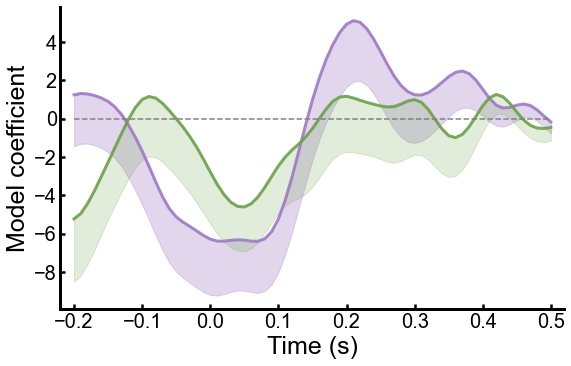

In [69]:
# line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
line_color = ['#E36A65', '#5CBBBF', '#FF943C', '#4482CD']  # 为每个参数选择不同的颜色
line_color = ['#9F79C6','#6BA147']    # 红色湖蓝色 正确快攻击，正确慢攻击 

# line_color = ['#669E40', '#9F78C6']    # 绿色 和 紫色
# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6
figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]

import matplotlib.pyplot as plt
import numpy as np
import os
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
plt.rcParams['font.family'] = 'Arial'
# the number of time axis
times = all_sub_human_epoch.times
for i in range(x_num):
    param = result[f'x{i+1}']['params']  
    cluster_p_values = result[f'x{i+1}']['cluster_p_values'] 
    clusters = result[f'x{i+1}']['clusters']   
    conf_int = result[f'x{i+1}']['conf_int'] 
    bse = result[f'x{i+1}']['bse']
    plt.plot(times, param, color=line_color[i], alpha=0.9, linewidth=3)
    # plt.fill_between(times, conf_int[:,0], conf_int[:,1], color=line_color[i], alpha=0.3)
    # plt.fill_between(times, param-bse, param+bse, color=line_color[i], alpha=0.3)
    plt.fill_between(times, param-bse, param, color=line_color[i], alpha=0.3)
    

    # 添加显著性标记
    for i_c, c in enumerate(clusters):
        # c = c[0]
        if cluster_p_values[i_c] <= 0.05:
            plt.plot(times[c[0] : c[1]], param[c[0] : c[1]], color=line_color[i], alpha=0.9, linewidth=10)


# 绘制result_2的数据 - 使用不同的线型区分
for i in range(x_num):
    param = result_2[f'x{i+1}']['params']  
    cluster_p_values = result_2[f'x{i+1}']['cluster_p_values'] 
    clusters = result_2[f'x{i+1}']['clusters']   
    conf_int = result_2[f'x{i+1}']['conf_int'] 
    bse = result_2[f'x{i+1}']['bse']
    plt.plot(times, param, color=line_color[1], alpha=0.9, linewidth=3)
    plt.fill_between(times, param-bse, param, color=line_color[1], alpha=0.2)  # 降低透明度区分
    
    # 添加显著性标记
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= 0.05:
            plt.plot(times[c[0] : c[1]], param[c[0] : c[1]], color=line_color[i], alpha=0.9, linewidth=10, linestyle='--')


plt.plot(times, np.zeros(len(times)), color="gray", linestyle="--")
# plt.legend( fontsize=legend_size, frameon=False, loc='upper left')
# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-2.5, 3])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Model coefficient", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

In [18]:
from pathlib import Path
import pandas as pd
behavior_path = Path("C:/Users/zhm58/Downloads")
file_path = behavior_path / f"wpli_all.csv"
df = pd.read_csv(file_path)

df_temp = df.copy() # Avoid SettingWithCopyWarning
df_temp['connection_id'] = df_temp.groupby('subject').cumcount()

# Pivot to wide format: subjects as index, connection_ids as columns, values as entries
wide_df = df_temp.pivot(index='subject', columns='connection_id', values='coh_att')

# !!! Crucially, DO NOT use fillna(0) here.
# Pandas .corr() will automatically perform pairwise deletion of rows (features/connection_ids)
# when calculating correlation between two columns (subjects). This means that for any
# two subjects, their correlation will only be based on the connection_ids for which
# both subjects have non-NaN values. This effectively uses the "shorter length" for each pair.

# Check for sufficient data to create a meaningful RDM
if wide_df.shape[0] < 2: # Need at least two subjects to correlate
    print(f"Warning: Not enough subjects ({wide_df.shape[0]}) after pivoting to create RDM. Skipping.")

if wide_df.shape[1] == 0: # Need at least one common feature across *some* subjects
    print(f"Warning: No common features ({wide_df.shape[1]}) after pivoting to create RDM. Skipping.")


# Calculate Pearson correlation between subjects (columns of wide_df.T)
# The result will be an RDM where cells contain correlations.
rdm = wide_df.T.corr(method='pearson')

In [10]:
rdm

subject,108,110,111,112,113,116,117,119,122,124,...,130,131,134,135,136,137,138,140,143,144
subject,,,,,,,,,,,,,,,,,,,,,
108,1.000000,0.006818,-0.119709,-0.402314,0.170373,-0.622574,-0.385618,0.069048,0.365472,-0.252638,...,-0.158349,0.542048,0.104240,-0.044422,-0.310912,0.079971,0.231008,0.602951,0.040282,0.228525
110,0.006818,1.000000,0.274129,0.598652,0.054439,-0.004351,0.053429,0.138731,-0.013400,0.337468,...,-0.277846,0.134927,0.048221,-0.184120,0.144549,-0.135970,0.337426,0.045879,-0.060039,-0.051945
111,-0.119709,0.274129,1.000000,0.696008,0.051122,0.114648,0.068651,0.055429,0.093675,-0.031634,...,-0.279396,0.049099,0.340761,0.241379,0.167168,-0.161224,-0.138699,0.067718,-0.221606,0.047862
112,-0.402314,0.598652,0.696008,1.000000,-0.370534,0.250960,0.276012,0.169259,0.228594,-0.070324,...,-0.437712,0.212183,0.809606,0.557789,0.610515,-0.904542,-0.008451,-0.426799,-0.571314,-0.075381
113,0.170373,0.054439,0.051122,-0.370534,1.000000,0.244745,-0.331668,-0.357596,-0.030626,-0.544413,...,0.003715,-0.134149,-0.226158,0.209230,0.196111,0.182497,-0.100537,0.513151,0.773012,-0.053160
116,-0.622574,-0.004351,0.114648,0.250960,0.244745,1.000000,-0.095380,-0.190134,-0.153790,0.243581,...,-0.075322,-0.036158,-0.254560,0.469300,0.019566,-0.029828,-0.049744,-0.387440,0.233072,0.153129
117,-0.385618,0.053429,0.068651,0.276012,-0.331668,-0.095380,1.000000,0.369772,-0.487674,0.274763,...,0.120601,-0.207131,0.128990,-0.216791,0.048590,0.046677,0.033767,-0.541071,-0.310663,0.156200
119,0.069048,0.138731,0.055429,0.169259,-0.357596,-0.190134,0.369772,1.000000,-0.382381,0.041728,...,-0.288459,-0.032450,0.200105,-0.180715,-0.136332,0.029995,-0.097713,-0.323546,-0.747289,0.066797
122,0.365472,-0.013400,0.093675,0.228594,-0.030626,-0.153790,-0.487674,-0.382381,1.000000,-0.613251,...,0.033610,0.196179,0.169609,0.516024,0.212723,-0.074113,0.038027,0.362711,0.136852,-0.027857


In [8]:
rdm

subject,108,110,111,112,113,116,117,119,122,124,...,130,131,134,135,136,137,138,140,143,144
subject,,,,,,,,,,,,,,,,,,,,,
108,1.000000,0.006818,-0.119709,-0.402314,0.170373,-0.622574,-0.385618,0.069048,0.365472,-0.252638,...,-0.158349,0.542048,0.104240,-0.044422,-0.310912,0.079971,0.231008,0.602951,0.040282,0.228525
110,0.006818,1.000000,0.274129,0.598652,0.054439,-0.004351,0.053429,0.138731,-0.013400,0.337468,...,-0.277846,0.134927,0.048221,-0.184120,0.144549,-0.135970,0.337426,0.045879,-0.060039,-0.051945
111,-0.119709,0.274129,1.000000,0.696008,0.051122,0.114648,0.068651,0.055429,0.093675,-0.031634,...,-0.279396,0.049099,0.340761,0.241379,0.167168,-0.161224,-0.138699,0.067718,-0.221606,0.047862
112,-0.402314,0.598652,0.696008,1.000000,-0.370534,0.250960,0.276012,0.169259,0.228594,-0.070324,...,-0.437712,0.212183,0.809606,0.557789,0.610515,-0.904542,-0.008451,-0.426799,-0.571314,-0.075381
113,0.170373,0.054439,0.051122,-0.370534,1.000000,0.244745,-0.331668,-0.357596,-0.030626,-0.544413,...,0.003715,-0.134149,-0.226158,0.209230,0.196111,0.182497,-0.100537,0.513151,0.773012,-0.053160
116,-0.622574,-0.004351,0.114648,0.250960,0.244745,1.000000,-0.095380,-0.190134,-0.153790,0.243581,...,-0.075322,-0.036158,-0.254560,0.469300,0.019566,-0.029828,-0.049744,-0.387440,0.233072,0.153129
117,-0.385618,0.053429,0.068651,0.276012,-0.331668,-0.095380,1.000000,0.369772,-0.487674,0.274763,...,0.120601,-0.207131,0.128990,-0.216791,0.048590,0.046677,0.033767,-0.541071,-0.310663,0.156200
119,0.069048,0.138731,0.055429,0.169259,-0.357596,-0.190134,0.369772,1.000000,-0.382381,0.041728,...,-0.288459,-0.032450,0.200105,-0.180715,-0.136332,0.029995,-0.097713,-0.323546,-0.747289,0.066797
122,0.365472,-0.013400,0.093675,0.228594,-0.030626,-0.153790,-0.487674,-0.382381,1.000000,-0.613251,...,0.033610,0.196179,0.169609,0.516024,0.212723,-0.074113,0.038027,0.362711,0.136852,-0.027857


In [7]:
wide_df

connection_id,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
subject,,,,,,,,,,,,,,,,,,,,,
108,0.236294,0.077671,0.346923,0.180659,0.431487,0.355938,0.061954,0.326310,0.067638,0.173062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,0.289194,0.609829,0.074301,0.432458,0.628098,0.166426,0.168019,0.420265,0.520728,0.031654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,0.095467,0.593667,0.024629,0.862135,0.462021,0.085908,0.061611,0.310951,0.073043,0.363681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,0.418308,0.511961,0.028725,0.495625,0.212630,0.271003,0.133888,0.297788,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,0.034900,0.386390,0.329300,0.281600,0.436730,0.660824,0.687718,0.040183,0.084876,0.204244,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,0.106681,0.788888,0.112298,0.681421,0.230528,0.609905,0.968768,0.617975,0.824963,0.218501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,0.303225,0.757611,0.699331,0.691994,0.060331,0.147155,0.242278,0.867698,0.695576,0.910881,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,0.435900,0.616433,0.533163,0.215792,0.236449,0.084333,0.164570,0.421108,0.312921,0.292326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122,0.502965,0.224874,0.101657,0.408456,0.433321,0.699231,0.324810,0.077720,0.070495,0.233826,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
